# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
# Import your chosen baseline model
# Example: from sklearn.linear_model import LogisticRegression
import h5py
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]


In [2]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
# df = pd.read_csv('your_dataset.csv')
#hf = h5py.File('.../ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5', 'r')
#labels_df = pd.read_csv('.../ML/data/Classification_table.csv', delimiter=';', usecols=['Symmetrie', 'Resolution'])

hf = h5py.File('/Users/katharinasteinkirchner/Documents/Machine Learning/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5', 'r')
labels_df = pd.read_excel('/Users/katharinasteinkirchner/Documents/Machine Learning/Classification_table_Version2.xlsx', usecols=['Resolution'])

# Feature selection
# Example: Selecting only two features for a simple baseline model
#X = hf['entry/acquisition/data']
general_group = hf.get('entry')
acquisition_group = general_group.get('acquisition')
data = acquisition_group.get('data')

# Samples nach vorne bringen
X = np.transpose(data, (2, 0, 1))

print(X.shape)
# (1765, 288, 216)

# Flatten
X = X.reshape(1765, -1)
print(X.shape)

y = labels_df['Resolution']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(1765, 288, 216)
(1765, 62208)


## Implementation

[Implement your baseline model here.]



In [3]:
# Initialize and train the baseline model
# Example for a classification problem using Logistic Regression
# model = LogisticRegression()
# model.fit(X_train, y_train)

# Your implementation code here
model = Pipeline([
    ("pca", PCA(n_components=50)),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,62208
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many sa

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]



In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
# Evaluate the baseline model
# Example for a classification problem
# y_pred = model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)

# For a regression problem, you might use:
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1-Score: {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.819
Macro F1-Score: 0.767

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       125
           1       0.76      0.89      0.82        18
           2       0.67      0.40      0.50        35
           3       0.79      0.92      0.85       124
           4       0.82      0.78      0.80        51

    accuracy                           0.82       353
   macro avg       0.79      0.77      0.77       353
weighted avg       0.82      0.82      0.81       353


Confusion Matrix:
[[105   4   6   7   3]
 [  2  16   0   0   0]
 [  6   1  14  14   0]
 [  3   0   1 114   6]
 [  1   0   0  10  40]]


In [6]:
# cross-validation score 
from sklearn.model_selection import cross_val_score 
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean()}")
print(f"Standard Deviation of CV scores: {cv_scores.std():.3f}")


Cross-validation scores: [0.5694051  0.79320113 0.78186969 0.76203966 0.7082153 ]
Mean CV score: 0.7229461756373937
Standard Deviation of CV scores: 0.082


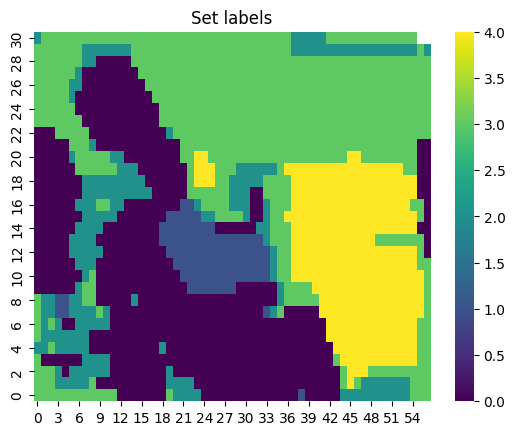

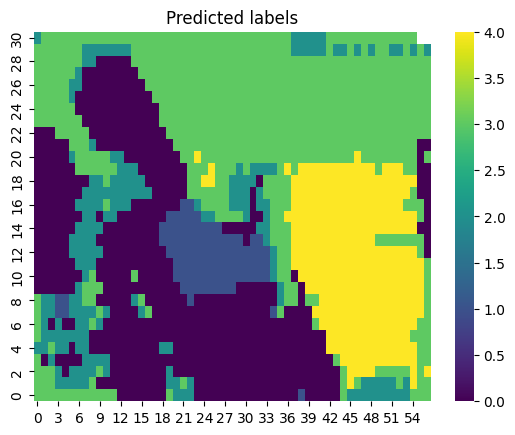

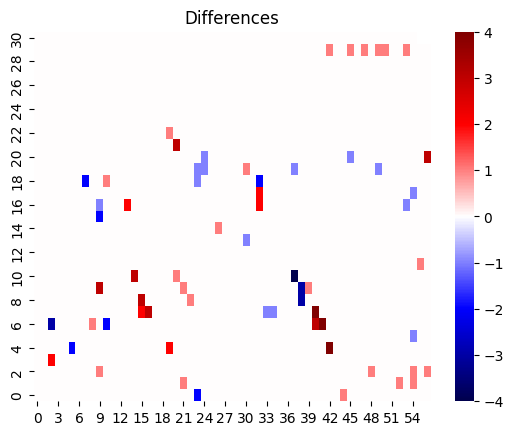

In [7]:
# heatmaps to show label distribution

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x = 57 # number of measurements (ARPES spectra) in x direction on sample

y_pred_full = model.predict(X).astype(float)  # Convert to float for NaN padding

arr = y_pred_full
pad_len = (-len(arr)) % x
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

true_matrix = y.astype(float).values
pad_len_true = (-len(true_matrix)) % x
true_matrix_padded = np.pad(true_matrix, (0, pad_len_true), constant_values=np.nan)
true_matrix = true_matrix_padded.reshape(-1, x)

diff_matrix = pred_matrix - true_matrix

# Ground truth
ax = sns.heatmap(
    true_matrix,
    cmap='viridis',
    cbar=True
)
ax.invert_yaxis()
plt.title("Set labels")
plt.show() 

# Predictions
ax = sns.heatmap(
    pred_matrix,
    cmap='viridis',
    cbar=True
)
ax.invert_yaxis()
plt.title("Predicted labels")
plt.show()

# Differences
ax = sns.heatmap(
    diff_matrix,
    cmap='seismic',
    vmin=-4,
    vmax=4,
    cbar=True
)

ax.invert_yaxis()
plt.title("Differences")
plt.show()

(288, 216, 67)
(1296, 288, 216)
Predicted class distribution:
0.0 547
2.0 745
4.0 4
0
Total samples: 1296, Padded samples: 1296


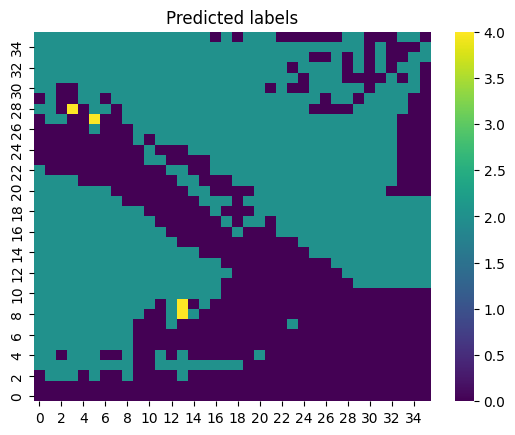

In [10]:
h5_path_3 = "/Users/katharinasteinkirchner/Documents/Machine Learning/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5"

with h5py.File(h5_path_3, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

    x = 36
    X_test2 = np.transpose(data[...], (2, 0, 1))
    print(X_test2.shape)
    X_test2 = X_test2.reshape(num_samples, -1)

    y_pred_full2 = model.predict(X_test2).astype(float)

unique, counts = np.unique(y_pred_full2, return_counts=True)

# Debug: Show predicted class distribution
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

arr = np.asarray(y_pred_full2, dtype=float)
pad_len = (-len(arr)) % x
print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

# Predictions
ax = sns.heatmap(
    pred_matrix,
    cmap='viridis',
    vmin=0,
    vmax=4,
    cbar=True
)
ax.invert_yaxis()
plt.title("Predicted labels")
plt.show()


(288, 216, 67)
(4453, 288, 216)
Predicted class distribution:
0.0 4444
2.0 9
0
Total samples: 4453, Padded samples: 4453


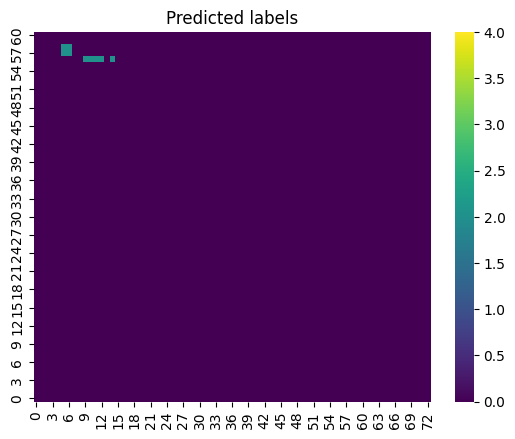

In [11]:
h5_path_4 = '/Users/katharinasteinkirchner/Documents/Machine Learning/x_y_grid_11eV_Laser_20260313_160306_037_z000000_snapshot_20260622_163304.h5'
with h5py.File(h5_path_4, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

    x = 73
    X_test2 = np.transpose(data[...], (2, 0, 1))
    print(X_test2.shape)
    X_test2 = X_test2.reshape(num_samples, -1)

    y_pred_full2 = model.predict(X_test2).astype(float)

unique, counts = np.unique(y_pred_full2, return_counts=True)

# Debug: Show predicted class distribution
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

arr = np.asarray(y_pred_full2, dtype=float)
pad_len = (-len(arr)) % x
print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

# Predictions
ax = sns.heatmap(
    pred_matrix,
    cmap='viridis',
    vmin=0,
    vmax=4,
    cbar=True
)
ax.invert_yaxis()
plt.title("Predicted labels")
plt.show()
